# Problem

**State Space**

The state space consists of two discrete states:
$$
\mathcal{X} = \{0, 1\}.
$$

These can be interpreted as two different situations or system configurations, for instance, a “low-performance” state (0) and a “high-performance” state (1).

 **Action Space**

The action space consists of two discrete actions:
$$
\mathcal{A} = \{0, 1\}.
$$

These actions can be thought of as two control options available to the agent — for example:

* **Action 0**: Conservative or “stay” action (keeps the system near state 0)
* **Action 1**: Aggressive or “move” action (pushes the system toward state 1)

**Reward Function**

The reward is explicitly given by:
$$
r(x,a) = x + a.
$$

This means:
* Rewards increase with higher actions.
* Being in the “high” state (1) also provides additional reward.

**Transition Function**

Deterministic transition dynamics:

* If the agent takes **action 0**, it always transitions to state 0.
* If the agent takes **action 1**, it always transitions to state 1.

In tabular form:

| Current (x,a) | P(x′=0) | P(x′=1) |
| ------------- | ------- | ------- |
| (0,0)         | 1.0     | 0.0     |
| (0,1)         | 0.0     | 1.0     |
| (1,0)         | 1.0     | 0.0     |
| (1,1)         | 0.0     | 1.0     |

In [1]:
%load_ext autoreload
%autoreload 2

import random
import sys
from pathlib import Path

import numpy as np
import torch

SEED = 42
DEVICE = "cpu"
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def tensor64(data):
    return torch.as_tensor(data, dtype=torch.float64, device=DEVICE)


def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path


PROJECT_ROOT = find_root(Path.cwd())

# Clean datasets/results folders
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets_clean"
RESULTS_DIR = PROJECT_ROOT / "data" / "results_clean" / "2states"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

DATASETS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Example dataset path for saving/loading new clean datasets
dataset_path = DATASETS_DIR / "dataset.pt"

# Add src to Python path
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rl_methods.mdp_clean import DiscreteMDP, Planner
from rl_methods.data_collection_clean import DiscreteDataBuffer, DatasetAnalyzer
from rl_methods.fogas_clean import (
    FOGASSolver,
    FOGASOracleSolver,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
    FOGASParameters,
)

# Tabular Features

## Definition

**Feature Map** 

We use a one-hot feature representation over state–action pairs.  
Each feature corresponds to a unique \((x,a)\) combination.

The feature map is defined as:
$$
\phi(x,a) \in \mathbb{R}^4
$$

with the ordering:
$$
(0,0) \rightarrow e_0,\quad
(0,1) \rightarrow e_1,\quad
(1,0) \rightarrow e_2,\quad
(1,1) \rightarrow e_3
$$

**Reward Weights**

The reward function is linear in the features:
$$
r(x,a) = \phi(x,a)^\top \omega,
$$

with weight vector:
$$
\omega =
\begin{bmatrix}
0 \\
1 \\
1 \\
2
\end{bmatrix}.
$$

**Transition Weights**

The transition model is also linear in the features:
$$
p(x' \mid x,a) = \phi(x,a)^\top \psi(x').
$$

The transition weight vectors are:
$$
\psi(0) =
\begin{bmatrix}
1 \\
0 \\
1 \\
0
\end{bmatrix},
\quad
\psi(1) =
\begin{bmatrix}
0 \\
1 \\
0 \\
1
\end{bmatrix}.
$$


## Testing

In [2]:
states_2d = torch.arange(2, dtype=torch.long)
actions_2d = torch.arange(2, dtype=torch.long)
gamma_2d = 0.99
x_0 = 0

def phi(state, action):
    vec = torch.zeros(4, dtype=torch.float64)
    vec[int(state) * 2 + int(action)] = 1.0
    return vec

omega = tensor64([0, 1.0, 1.0, 2.0])

psi = {
    0: tensor64([1.0, 0, 1.0, 0]),
    1: tensor64([0, 1.0, 0, 1.0]),
}

mdp = DiscreteMDP(
    states=states_2d,
    actions=actions_2d,
    gamma=gamma_2d,
    x0=x_0,
    omega=omega,
    psi=psi,
    phi=phi, 
)

planner = Planner(mdp)

### Oracle

In [3]:
solver = FOGASOracleSolver(
    planner=planner,
    phi=phi,
    cov_matrix="identity",
    print_params=True,
    T=1000,
    seed=SEED,
    device=DEVICE,
)

evaluator = FOGASEvaluator(solver, planner=planner)

optimizer = FOGASHyperOptimizer(
    solver=solver,
    evaluator=evaluator,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 5,
        "seed": SEED,
        "maximize": True,
    },
    seed=SEED,
)


================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           10000000
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      4627564.263195183
T (iterations):                1000   (overridden → 1000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000186
rho:                            7.292126
eta:                            0.000015
D_theta:                    20.000000
beta (ridge):             0.000250
D_pi (derived):           3.723297




In [4]:
summary= optimizer.optimize(
    mode="grid",
    parameters=("eta", "rho", "alpha", "D_theta"),
    values={
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=1,
    plot=False,
    print_summary=True,
    progress=True,
    grid_n_jobs=1,
    results_output=RESULTS_DIR / "oracle_search"
)

alpha_star = summary["best_params"]["alpha"]
rho_star = summary["best_params"]["rho"]
eta_star = summary["best_params"]["eta"]
D_theta_star = summary["best_params"]["D_theta"]

FOGAS hyperopt:   0%|          | 0/750 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('eta', 'rho', 'alpha', 'D_theta')
Evaluated candidates: 750
Best metric: -8.80199
Best params: alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-03, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+02

Top 5 candidates:
1. metric=-8.80199 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-03, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+02
2. metric=-8.80199 | stage=grid | alpha=1.0000e-02, rho=1.0000e-01, eta=1.0000e-03, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+02
3. metric=-8.80199 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-02, T=1000, D_theta=1.0000e+00, D_pi=1.0000e+01
4. metric=-8.80199 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-02, T=1000, D_theta=5.0000e+00, D_pi=5.0000e+01
5. metric=-8.80199 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-02, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+02


In [5]:
solver.run(alpha=alpha_star, eta=eta_star, rho=rho_star, T = 10000, tqdm_print=True)
evaluator.compare_value_functions()

reward_comparison = evaluator.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS Oracle: 100%|██████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:03<00:00, 3192.92it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^pi(x) =  199.000000 | delta =  0.000000e+00
State 1: V*(x) =  200.000000 | V^pi(x) =  200.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^pi(x,a) =  197.010000 | delta =  0.000000e+00
(x=0, a=1): Q*(x,a) =  199.000000 | Q^pi(x,a) =  199.000000 | delta =  0.000000e+00
(x=1, a=0): Q*(x,a) =  198.010000 | Q^pi(x,a) =  198.010000 | delta =  0.000000e+00
(x=1, a=1): Q*(x,a) =  200.000000 | Q^pi(x,a) =  200.000000 | delta =  0.000000e+00

Norm diagnostics:
||V^pi - V*||_2 = 0.000000e+00
||Q^pi - Q*||_2 = 0.000000e+00


Solver average return: 8.801990020000002
Optimal average return: 8.801990020000002
Gap: 0.0


### Dataset creation

In [22]:
dataset_path = DATASETS_DIR / "2states.csv"

collector = DiscreteDataBuffer(
    mdp=mdp,
    max_steps=100,
    seed=SEED,
)

df = collector.collect(
    policy="random",
    n_steps=500,
    extra_terminal_steps=3,
    save_path=str(dataset_path),
    verbose=True,
)

Collected 500 transitions over 5 episodes.
Policy distribution:
policy_id
0    1.0
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
x0    1.0
Name: proportion, dtype: float64
Saved FOGAS dataset to /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/2states.csv


### Empirical

In [ ]:
solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=str(DATASETS_DIR / "2states.csv"),
    print_params=True,
    seed=SEED,
    device=DEVICE,
    T = 10000,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 5,
        "seed": SEED,
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /shared/home/mauro.diaz/work/FOGAS/data/datasets_clean/2states.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      231.37821315975916
T (iterations):                10000   (overridden → 10000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000059
rho:                            1137.802529
eta:                            0.000005
D_theta:                    20.000000
beta (ridge):             0.000025
D_pi (derived):           11.774100




Trying same optimal hyperparameters found for the oracle.

In [13]:
solver_e.run(
    alpha=alpha_star,
    eta=eta_star,
    rho=rho_star,
    D_theta=D_theta_star,
    T = 10000,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS: 100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 3627.26it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^pi(x) =  148.440872 | delta = -5.055913e+01
State 1: V*(x) =  200.000000 | V^pi(x) =  148.962124 | delta = -5.103788e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^pi(x,a) =  146.956463 | delta = -5.005354e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^pi(x,a) =  148.472503 | delta = -5.052750e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^pi(x,a) =  147.956463 | delta = -5.005354e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^pi(x,a) =  149.472503 | delta = -5.052750e+01

Norm diagnostics:
||V^pi - V*||_2 = 7.184073e+01
||Q^pi - Q*||_2 = 1.005822e+02


Solver average return: 7.037731018
Optimal average return: 8.801990020000002
Gap: 1.764259002000002


FOGAS hyperopt:   0%|          | 0/750 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('alpha', 'eta', 'D_theta', 'rho')
Evaluated candidates: 750
Best metric: -8.80199
Best params: alpha=1.0000e-01, rho=1.0000e-01, eta=1.0000e-02, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+03

Top 5 candidates:
1. metric=-8.80199 | stage=grid | alpha=1.0000e-01, rho=1.0000e-01, eta=1.0000e-02, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+03
2. metric=-8.80199 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-06, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+04
3. metric=-8.80199 | stage=grid | alpha=1.0000e+00, rho=1.0000e+00, eta=1.0000e-06, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+04
4. metric=-8.80199 | stage=grid | alpha=1.0000e+00, rho=1.0000e+02, eta=1.0000e-06, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+04
5. metric=-8.80199 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-05, T=1000, D_theta=2.0000e+01, D_pi=2.0000e+04


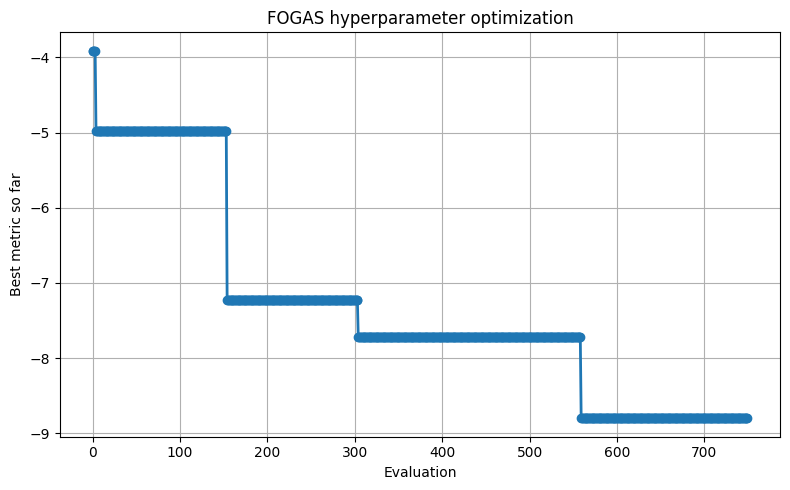

In [8]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("alpha", "eta", "D_theta", "rho"),
    values={
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=1,
    plot=True,
    print_summary=True,
    progress=True,
)

alpha_star_e = summary_e["best_params"]["alpha"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]
rho_star_e = summary_e["best_params"]["rho"]

In [16]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    D_theta=D_theta_star_e,
    rho=rho_star_e,
    tqdm_print=True,
    T = 1000,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison_e = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison_e["policy"])
print("Optimal average return:", reward_comparison_e["optimal"])
print("Gap:", reward_comparison_e["difference"])

FOGAS: 100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3534.72it/s]



========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^pi(x) =  188.043593 | delta = -1.095641e+01
State 1: V*(x) =  200.000000 | V^pi(x) =  188.933487 | delta = -1.106651e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^pi(x,a) =  186.163157 | delta = -1.084684e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^pi(x,a) =  188.044152 | delta = -1.095585e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^pi(x,a) =  187.163157 | delta = -1.084684e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^pi(x,a) =  189.044152 | delta = -1.095585e+01

Norm diagnostics:
||V^pi - V*||_2 = 1.557275e+01
||Q^pi - Q*||_2 = 2.180296e+01


Solver average return: 8.801990020000002
Optimal average return: 8.801990020000002
Gap: 0.0


In [17]:
evaluator_e.print_solver_policy()

  State 0: pi(a=0|s=0) = 0.00  pi(a=1|s=0) = 1.00  --> best action: 1
  State 1: pi(a=0|s=1) = 0.06  pi(a=1|s=1) = 0.94  --> best action: 1



# Funky Features

## Definition

**Feature Map**

The MDP follows the **Linear MDP assumption**, where both the reward and transition dynamics are linear in a known feature map $ \phi(x,a) $.

The feature representation is defined as:
$$
\phi(x,a) = 2 *
\begin{bmatrix}
1 \\
x \\
a
\end{bmatrix}
\in \mathbb{R}^3.
$$

**Reward Function**

The reward function is a linear combination of the feature vector:
$$
r(x,a) = \phi(x,a)^\top \omega,
$$
with the weight vector
$$
\omega = \frac{1}{2}
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}.
$$

**Transition Function**

The transition model is also linear in the features.
We define a collection of transition weight vectors $ \psi(x') $ such that
$$
p(x'|x,a) = \phi(x,a)^\top \psi(x').
$$

Specifically, the weights are:
$$
\psi(0) = \frac{1}{2}
\begin{bmatrix}
1 \\
0 \\
-1
\end{bmatrix}, \quad
\psi(1) = \frac{1}{2}
\begin{bmatrix}
0 \\
0 \\
1
\end{bmatrix}.
$$

## Testing

In [18]:
states_2d = torch.arange(2, dtype=torch.long)
actions_2d = torch.arange(2, dtype=torch.long)

gamma_2d = 0.99
x_0 = 0

def phi(state, action):
    return 2.0 * tensor64([1.0, float(state), float(action)])

omega = tensor64([0.0, 0.5, 0.5])

psi = {
    0: 0.5 * tensor64([1.0, 0.0, -1.0]),
    1: 0.5 * tensor64([0.0, 0.0, 1.0]),
}

mdp = DiscreteMDP(
    states=states_2d,
    actions=actions_2d,
    gamma=gamma_2d,
    x0=x_0,
    phi=phi,
    omega=omega,
    psi=psi,
)

planner = Planner(mdp)

### Empirical

In [19]:
dataset_path = DATASETS_DIR / "2states.csv"

solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=str(dataset_path),
    print_params=True,
    seed=SEED,
    T = 2000,
    device="cpu",
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 5,
        "seed": SEED,
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /shared/home/mauro.diaz/work/FOGAS/data/datasets_clean/2states.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     3.4641
Num states N:             2
Num actions A:            2
Feature dim d:            3
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      2776.5385579171098
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000044
rho:                            798.342432
eta:                            0.000004
D_theta:                    17.320508
beta (ridge):             0.002000
D_pi (derived):           1.520030




FOGAS hyperopt:   0%|          | 0/450 [00:00<?, ?candidate/s]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('eta', 'rho', 'alpha', 'D_theta')
Evaluated candidates: 450
Best metric: -8.80199
Best params: alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+02

Top 5 candidates:
1. metric=-8.80199 | stage=grid | alpha=1.0000e-02, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+02
2. metric=-8.80199 | stage=grid | alpha=1.0000e-01, rho=1.0000e-01, eta=1.0000e-04, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+03
3. metric=-8.80199 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+03
4. metric=-8.80199 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+03
5. metric=-8.80199 | stage=grid | alpha=1.0000e-01, rho=1.0000e-01, eta=1.0000e-03, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+03


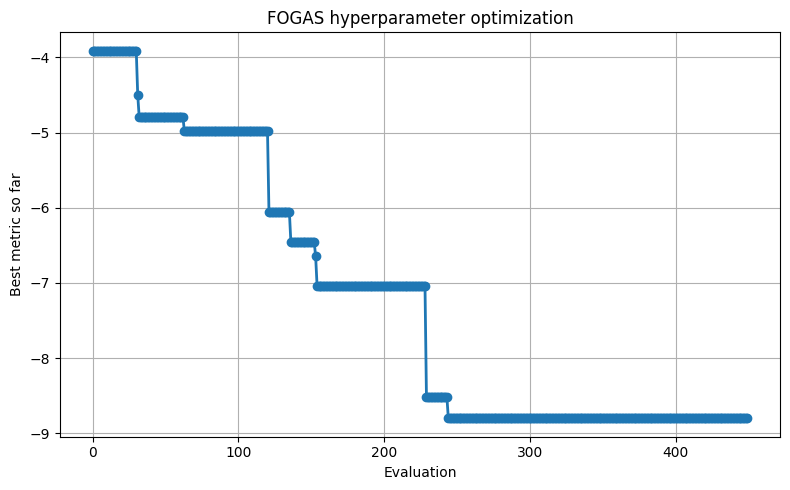

In [21]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("eta", "rho", "alpha", "D_theta"),
    values={
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=1,
    plot=True,
    print_summary=True,
    progress=True,
    # grid_n_jobs=8,
)

alpha_star_e = summary_e["best_params"]["alpha"]
rho_star_e = summary_e["best_params"]["rho"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]

In [22]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    rho=rho_star_e,
    D_theta=D_theta_star_e,
    T = 10000,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS: 100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 3649.42it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^pi(x) =  190.284366 | delta = -8.715634e+00
State 1: V*(x) =  200.000000 | V^pi(x) =  191.284366 | delta = -8.715634e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^pi(x,a) =  188.381522 | delta = -8.628478e+00
(x=0, a=1): Q*(x,a) =  199.000000 | Q^pi(x,a) =  190.371522 | delta = -8.628478e+00
(x=1, a=0): Q*(x,a) =  198.010000 | Q^pi(x,a) =  189.381522 | delta = -8.628478e+00
(x=1, a=1): Q*(x,a) =  200.000000 | Q^pi(x,a) =  191.371522 | delta = -8.628478e+00

Norm diagnostics:
||V^pi - V*||_2 = 1.232577e+01
||Q^pi - Q*||_2 = 1.725696e+01


Solver average return: 8.801990020000002
Optimal average return: 8.801990020000002
Gap: 0.0
